# Reflection on OOD

<div style="text-align: justify">

Notebook used to perform OOD checks on the input train data. No monitoring is actually performed here, but functions are defined and tested for later integration into the monitoring pipeline. This notebook is independent to ML model training, as it focuses on the input data and computes metrics prior to ML inference.
</div>

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

In [2]:
from pathlib import Path
from typing import Dict

import cv2
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

from swmf.data import create_dataloader

In [31]:
PATH_TO_EXPORTED_LARD = "../data/datasets/lard_512x512_ICPR2026"

In [32]:
lard_data_dpath = Path(PATH_TO_EXPORTED_LARD).resolve()
split_fpath = lard_data_dpath / "split_trainval_per_runway.csv"
split_dname = split_fpath.stem

print("Root path to lard exported data:", lard_data_dpath.as_posix())
print("Path to train split description:", split_fpath.as_posix())
print("Name of the split strategy directory:", split_dname)

Root path to lard exported data: /home/dariom/Workspace/LARD_monitoring/data/datasets/lard_512x512_ICPR2026
Path to train split description: /home/dariom/Workspace/LARD_monitoring/data/datasets/lard_512x512_ICPR2026/split_trainval_per_runway.csv
Name of the split strategy directory: split_trainval_per_runway


In [33]:
train_dataloader = create_dataloader(
    dataset_dpath=lard_data_dpath,
    yolo_task="detect",
    data_mode="train",
    using_split=True,
    split_fpath=split_fpath,
    split="train",
    batch_size=16,
)

valid_dataloader = create_dataloader(
    dataset_dpath=lard_data_dpath,
    yolo_task="detect",
    data_mode="train",
    using_split=True,
    split_fpath=split_fpath,
    split="valid",
    batch_size=4
)

## Image properties

### 1. Image brightness level

In [34]:
def compute_img_mean_brightness(im: torch.Tensor) -> torch.Tensor:
    """
    Compute the mean brightness level of the given image.

    Note:
        The luminance formula for grayscale conversion:
            (0.2989 * R + 0.5870 * G + 0.1140 * B)

    Args:
        im (torch.Tensor, [N, C, H, W]): The image to compute the metrics on.

    Returns:
        (torch.Tensor, [N,]) The mean brightness for every image of the batch.
    """
    # Make sure the im tensor is in [N, C, H, W] format
    if im.dim() == 3:
        im = im.unsqueeze(0)
    if im.dim() != 4:
        raise ValueError(f"Input image is expected to be 4-dimensional ([N,C,H,W]), received {im.dim()}-dim.")

    # Convert RGB to grayscale - by batch
    if im.shape[1] == 3:  # If image is RGB
        gray_im = 0.2989 * im[:, 0, :, :] + 0.5870 * im[:, 1, :, :] + 0.1140 * im[:, 2, :, :]
    else:  # If image is already grayscale
        gray_im = im

    # Compute average of all pixel values & divide by 255 to normalize to [0, 1]
    mean_brightness = gray_im.mean(dim=[1,2]).float() / 255.0

    return mean_brightness  # Return as torch.Tensor

### 2. Image saturation level

In [35]:
def compute_img_mean_saturation(im: torch.Tensor) -> torch.Tensor:
    """
    Compute the mean saturation level of the given image.

    Args:
        im (torch.Tensor): The image to compute the metrics on. [3, H, W]-torch or [H, W, 3]-numpy.
    
    Returns:
        (torch.Tensor, [N,]) The mean saturation level in [0, 1].
        The mean saturation level, in [0, 1].
    """
    # Make sure the im tensor is in [N, C, H, W] format
    if im.dim() == 3:
        im = im.unsqueeze(0)
    if im.dim() != 4:
        raise ValueError(f"Input image is expected to be 4-dimensional ([N,C,H,W]), received {im.dim()}-dim.")

    # Convert PyTorch tensor to NumPy array
    if im.shape[1] == 3:  # NCHW format
        im_np = im.permute(0, 2, 3, 1).numpy()  # Convert to HWC
    else:
        im_np = im.numpy()

    # Convert to HSV
    hsv_im = np.array([cv2.cvtColor(im, cv2.COLOR_RGB2HSV) for im in im_np])

    # Extract saturation channel (S) and compute mean
    mean_saturation = torch.Tensor(hsv_im[:, :, :, 1].mean(axis=(1,2))).float() / 255.0
    
    return mean_saturation

### 3. Image entropy (~contrast level)

In [36]:
def compute_img_mean_entropy(im: torch.Tensor) -> torch.Tensor:
    """
    Compute the mean entropy of the given image.

    Args:
        im (torch.Tensor): Input image tensor. [3, H, W].

    Returns:
        The mean entropy of the image, normalized by the maximum possible entropy.
    """
    # Make sure the im tensor is in [N, C, H, W] format
    if im.dim() == 3:
        im = im.unsqueeze(0)
    if im.dim() != 4:
        raise ValueError(f"Input image is expected to be 4-dimensional ([N,C,H,W]), received {im.dim()}-dim.")

    # Convert RGB to grayscale - by batch
    if im.shape[1] == 3:  # If image is RGB
        gray_im = 0.2989 * im[:, 0, :, :] + 0.5870 * im[:, 1, :, :] + 0.1140 * im[:, 2, :, :]
    else:  # If image is already grayscale
        gray_im = im

    # Convert to integer bins and compute histogram
    gray_im = gray_im.clamp(0, 255).round().to(torch.uint8)
    hist = torch.stack([torch.bincount(im.flatten(), minlength=256) for im in gray_im]).float()

    # Compute probabilities
    pixel_nb = gray_im[0].numel()
    prob = hist / pixel_nb + 1e-10  # Avoid log(0) by adding a small value

    # Compute entropy: H = -sum(p(i) * log2(p(i)))
    entropy = -torch.sum(prob * torch.log2(prob), dim=1)
    max_entropy = 8  # log2(256) = 8
    nrm_entropy = entropy / max_entropy

    return nrm_entropy  # Back to python floats

### 4. Amount of edges in image (~image complexity)

In [37]:
def compute_img_edge_amount(im: torch.Tensor) -> float:
    """
    Compute the edge amount of the given image.

    Args:
        im (torch.Tensor): Input image tensor. [3, H, W].
    
    Returns:
        The normalized edge amount, in [0, 1].
    """
    # Make sure the im tensor is in [N, C, H, W] format
    if im.dim() == 3:
        im = im.unsqueeze(0)
    if im.dim() != 4:
        raise ValueError(f"Input image is expected to be 4-dimensional ([N,C,H,W]), received {im.dim()}-dim.")

    # Convert RGB to grayscale - by batch
    if im.shape[1] == 3:  # If image is RGB
        gray_im = 0.2989 * im[:, 0, :, :] + 0.5870 * im[:, 1, :, :] + 0.1140 * im[:, 2, :, :]
    else:  # If image is already grayscale
        gray_im = im

    # Enforce 2D grayscale and float32
    gray_im = gray_im.float()
    gray_im = gray_im.squeeze(1) if gray_im.dim() == 4 else gray_im

    # Apply Laplace filter (kernel size 3)
    laplace_kernel = torch.tensor([[1,  1, 1],
                                   [1, -8, 1],
                                   [1,  1, 1]], dtype=torch.float32, device=im.device)
    laplace_kernel = laplace_kernel.view(1, 1, 3, 3)  # Shape for conv2d
    filtered_im = F.conv2d(gray_im.unsqueeze(1), laplace_kernel, padding=1)
    filtered_im = filtered_im.squeeze(1)  # Remove channel dims

    # Count pixels with absolute value > 25 as edges
    edges_nb = (torch.abs(filtered_im) > 25).sum(dim=(1,2))
    total_nb = gray_im[0].numel()

    # Normalize edge amount to [0, 1]
    return edges_nb / total_nb

### Try out on a training sample

In [38]:
# Test functions
X, y = next(iter(train_dataloader))
im = X[0]

print("Mean brightness level:\n", compute_img_mean_brightness(im))
print("Mean saturation level:\n", compute_img_mean_saturation(im))
print("Mean entropy:\n", compute_img_mean_entropy(im))
print("Edge amount (norm):\n", compute_img_edge_amount(im))

Mean brightness level:
 tensor([0.4186])
Mean saturation level:
 tensor([0.4830])
Mean entropy:
 tensor([0.8747])
Edge amount (norm):
 tensor([0.1363])


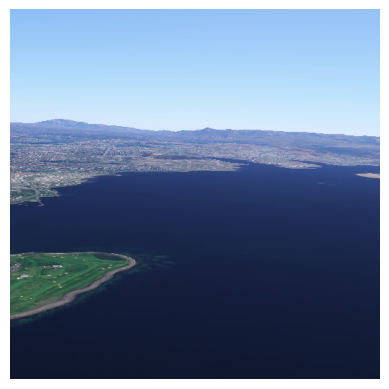

In [39]:
# Show image
import matplotlib.pyplot as plt

plt.imshow(im.permute(1,2,0))
plt.axis('off')
plt.show()

## Properties of the `train` dataset

In [40]:
b_lst = torch.Tensor([], device='cpu')  # List of all images brightness levels
s_lst = torch.Tensor([], device='cpu')  # List of all images saturation levels
h_lst = torch.Tensor([], device='cpu')  # List of all images entropy
e_lst = torch.Tensor([], device='cpu')  # List of all images edge amount

print("Computing properties for all training data...", flush=True, end=" ")
for X, _ in tqdm.tqdm(train_dataloader):
    # X = torch.stack(X)
    b_lst = torch.cat([b_lst, compute_img_mean_brightness(X)])
    s_lst = torch.cat([s_lst, compute_img_mean_saturation(X)])
    h_lst = torch.cat([h_lst, compute_img_mean_entropy(X)])
    e_lst = torch.cat([e_lst, compute_img_edge_amount(X)])
print("Done.")

Computing properties for all training data... 

100%|██████████| 401/401 [00:40<00:00,  9.99it/s]

Done.


In [41]:
b_npy = b_lst.numpy()
s_npy = s_lst.numpy()
h_npy = h_lst.numpy()
e_npy = e_lst.numpy()

print("Properties summary:")
print(f"- brightness : (N={b_npy.shape[0]}), [min={b_npy.min():.4f}, max={b_npy.max():.4f}, mean={b_npy.mean():.4f}, median={np.median(b_npy):.4f}]")
print(f"- saturation : (N={s_npy.shape[0]}), [min={s_npy.min():.4f}, max={s_npy.max():.4f}, mean={s_npy.mean():.4f}, median={np.median(s_npy):.4f}]")
print(f"- entropy    : (N={h_npy.shape[0]}), [min={h_npy.min():.4f}, max={h_npy.max():.4f}, mean={h_npy.mean():.4f}, median={np.median(h_npy):.4f}]")
print(f"- edge amount: (N={e_npy.shape[0]}), [min={e_npy.min():.4f}, max={e_npy.max():.4f}, mean={e_npy.mean():.4f}, median={np.median(e_npy):.4f}]")


Properties summary:
- brightness : (N=6410), [min=0.2999, max=0.7431, mean=0.5460, median=0.5467]
- saturation : (N=6410), [min=0.0956, max=0.5637, mean=0.3032, median=0.2940]
- entropy    : (N=6410), [min=0.7347, max=0.9722, mean=0.9103, median=0.9214]
- edge amount: (N=6410), [min=0.0656, max=0.6545, mean=0.4327, median=0.4663]


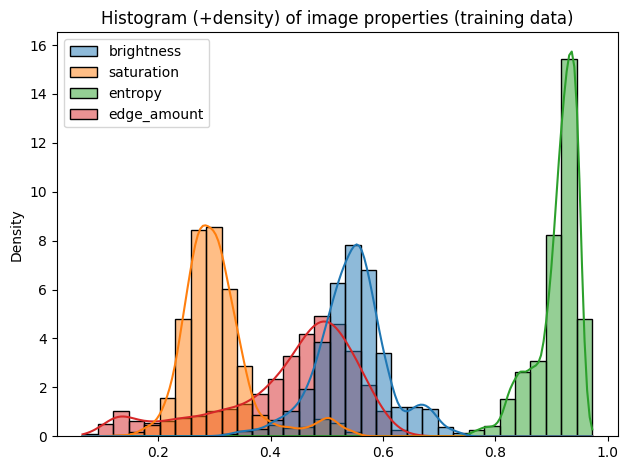

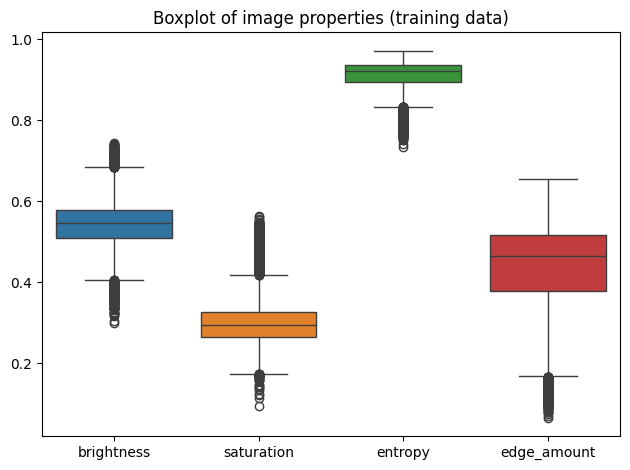

In [42]:
df_train = pd.DataFrame({
    'brightness': b_npy,
    'saturation': s_npy,
    'entropy': h_npy,
    'edge_amount': e_npy,
})

# Plot the histogram of the image properties (for distribution shape visualization)
sns.histplot(df_train, kde=True, stat="density", common_norm=False)
plt.title("Histogram (+density) of image properties (training data)")
plt.tight_layout()
plt.show()

# Plot the box plot of the image properties (for quantiles visualization)
sns.boxplot(df_train)
plt.title("Boxplot of image properties (training data)")
plt.tight_layout()
plt.show()

Beta fit to brightness  : a=32.2064, b=26.7800, loc=0.00, scale=1.00
Beta fit to saturation  : a=16.8866, b=38.7290, loc=0.00, scale=1.00
Beta fit to entropy     : a=60.3628, b= 5.9611, loc=0.00, scale=1.00
Beta fit to edge_amount : a= 5.9436, b= 7.9164, loc=0.00, scale=1.00


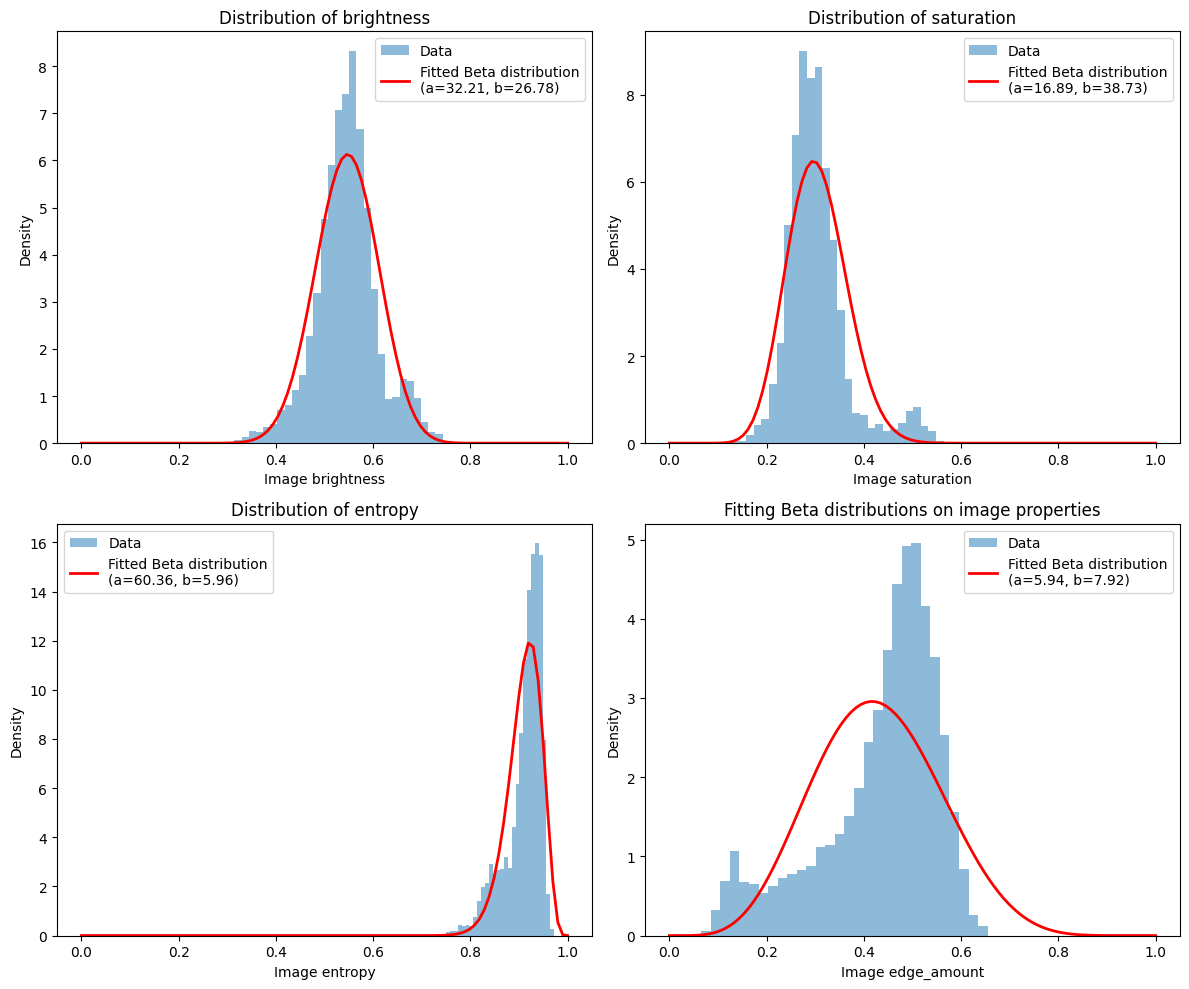

In [43]:
from scipy.stats import beta


fig, axs = plt.subplots(2, 2, figsize=(12,10))
axs = axs.flatten()

for i, key in enumerate(df_train.columns):
    # Fit a beta distribution on column
    a, b, loc, scale = beta.fit(df_train[key], floc=0, fscale=1)

    # Generate PDF for the fitted beta distribution
    x = np.linspace(0, 1, 100)
    pdf = beta.pdf(x, a, b, loc=loc, scale=scale)

    # Plot data histogram
    axs[i].hist(df_train[key], bins=30, density=True, alpha=0.5, label="Data")

    # Plot beta distribution PDF
    axs[i].plot(x, pdf, "r-", lw=2, label=f"Fitted Beta distribution\n(a={a:.2f}, b={b:.2f})")

    axs[i].set_title(f"Distribution of {key}")
    axs[i].set_xlabel(f'Image {key}')
    axs[i].set_ylabel('Density')
    axs[i].legend()

    print(f"Beta fit to {key:<12}: a={a:7.4f}, b={b:7.4f}, loc={loc:.2f}, scale={scale:.2f}")

plt.title("Fitting Beta distributions on image properties")
plt.tight_layout()
plt.show()

```
Beta fit to brightness  : a=33.1332, b=27.5422, loc=0.00, scale=1.00
Beta fit to saturation  : a=15.2404, b=34.0947, loc=0.00, scale=1.00
Beta fit to entropy     : a=65.6630, b= 6.5330, loc=0.00, scale=1.00
Beta fit to edge_amount : a= 5.3887, b= 7.2550, loc=0.00, scale=1.00
```

## OOD monitoring approaches

<div style='text-align: justify'>

In this section, we will perform OOD monitoring. We assume the data follows a Beta distribution, as explored in the previous section. Multiple approaches can be used to assert whether a new sample is OOD or not.
</div>

In [44]:
import scipy.stats as stats

In [45]:
PROP_BETA_DIST = {
    'brightness' : dict(a=33.1333, b=27.5422, loc=0.00, scale=1.00),
    'saturation' : dict(a=15.2404, b=34.0947, loc=0.00, scale=1.00),
    'entropy'    : dict(a=65.6630, b= 6.5330, loc=0.00, scale=1.00),
    'edge_amount': dict(a= 5.3887, b= 7.2550, loc=0.00, scale=1.00),
}

beta_dist = {k: stats.beta(**v) for k, v in PROP_BETA_DIST.items()}
beta_dist

{'brightness': <scipy.stats._distn_infrastructure.rv_continuous_frozen at 0x7f7d4c226620>,
 'saturation': <scipy.stats._distn_infrastructure.rv_continuous_frozen at 0x7f7d4c0c4610>,
 'entropy': <scipy.stats._distn_infrastructure.rv_continuous_frozen at 0x7f7d4c1906d0>,
 'edge_amount': <scipy.stats._distn_infrastructure.rv_continuous_frozen at 0x7f7d5dca1ea0>}

In [46]:
b_valid_lst = torch.Tensor([], device='cpu')  # List of all images brightness levels
s_valid_lst = torch.Tensor([], device='cpu')  # List of all images saturation levels
h_valid_lst = torch.Tensor([], device='cpu')  # List of all images entropy
e_valid_lst = torch.Tensor([], device='cpu')  # List of all images edge amount

print("Computing properties for all validation data...", flush=True, end=" ")
for X, _ in tqdm.tqdm(valid_dataloader):
    # X = torch.stack(X)
    b_valid_lst = torch.cat([b_valid_lst, compute_img_mean_brightness(X)])
    s_valid_lst = torch.cat([s_valid_lst, compute_img_mean_saturation(X)])
    h_valid_lst = torch.cat([h_valid_lst, compute_img_mean_entropy(X)])
    e_valid_lst = torch.cat([e_valid_lst, compute_img_edge_amount(X)])
print("Done.")

b_valid_npy = b_valid_lst.numpy()
s_valid_npy = s_valid_lst.numpy()
h_valid_npy = h_valid_lst.numpy()
e_valid_npy = e_valid_lst.numpy()

print("Properties summary:")
print(f"- brightness : (N={b_valid_npy.shape[0]}), [min={b_valid_npy.min():.4f}, max={b_valid_npy.max():.4f}, mean={b_valid_npy.mean():.4f}, median={np.median(b_valid_npy):.4f}]")
print(f"- saturation : (N={s_valid_npy.shape[0]}), [min={s_valid_npy.min():.4f}, max={s_valid_npy.max():.4f}, mean={s_valid_npy.mean():.4f}, median={np.median(s_valid_npy):.4f}]")
print(f"- entropy    : (N={h_valid_npy.shape[0]}), [min={h_valid_npy.min():.4f}, max={h_valid_npy.max():.4f}, mean={h_valid_npy.mean():.4f}, median={np.median(h_valid_npy):.4f}]")
print(f"- edge amount: (N={e_valid_npy.shape[0]}), [min={e_valid_npy.min():.4f}, max={e_valid_npy.max():.4f}, mean={e_valid_npy.mean():.4f}, median={np.median(e_valid_npy):.4f}]")


Computing properties for all validation data... 

100%|██████████| 365/365 [00:08<00:00, 40.99it/s]

Done.
Properties summary:
- brightness : (N=1458), [min=0.2568, max=0.6455, mean=0.5189, median=0.5162]
- saturation : (N=1458), [min=0.1665, max=0.4985, mean=0.3136, median=0.3048]
- entropy    : (N=1458), [min=0.7154, max=0.9539, mean=0.9180, median=0.9238]
- edge amount: (N=1458), [min=0.1098, max=0.6571, mean=0.4470, median=0.4752]


In [47]:
df_valid = pd.DataFrame({
    'brightness': b_valid_npy,
    'saturation': s_valid_npy,
    'entropy': h_valid_npy,
    'edge_amount': e_valid_npy,
})
df_valid.head()

,brightness,saturation,entropy,edge_amount
0,0.544276,0.337625,0.931989,0.367210
1,0.488424,0.328523,0.933015,0.385773
2,0.485448,0.313667,0.929288,0.394630
3,0.525560,0.357375,0.931218,0.335670
4,0.538140,0.316902,0.937475,0.399109


### A one-dimensional approach

<div style='text-align: justify'>

In this approach, we model the distribution of each feature with a Beta distribution (*brightness*, *saturation*, *entropy*, *edge amount*). For any new sample (image), if any property has a low likelihood with respect to the fitted distribution, we flag it as OOD.
</div>

#### The *percentile* approach

In [48]:
def check_OOD_1D_percentile(
        x: np.ndarray,
        beta: stats.rv_continuous,
        percent_to_cut: float=None,
        lower_bound: float=None,
        upper_bound: float=None,
):
    """"""
    if percent_to_cut is None and (lower_bound is None or upper_bound is None):
        raise ValueError("At least percent_to_cut or (lower_bound and upper_bound) should be specified")
    if lower_bound is None or upper_bound is None:
        lower_bound = percent_to_cut / 2.0
        upper_bound = 100.0 - percent_to_cut / 2.0
    
    p = beta.cdf(x) * 100
    return np.logical_or.reduce([lower_bound >= p, p >= upper_bound], axis=0)

In [49]:
### EDIT HERE ###
PERCENT_TO_CUT = 2
#################

for k in beta_dist.keys():
    df_valid[f'OOD_p_{k}'] = check_OOD_1D_percentile(df_valid[k], beta_dist[k], percent_to_cut=PERCENT_TO_CUT)

df_valid['OOD_by_any_1D'] = np.logical_or.reduce(df_valid[[f'OOD_p_{k}' for k in beta_dist.keys()]], axis=1)
df_valid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458 entries, 0 to 1457
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   brightness         1458 non-null   float32
 1   saturation         1458 non-null   float32
 2   entropy            1458 non-null   float32
 3   edge_amount        1458 non-null   float32
 4   OOD_p_brightness   1458 non-null   bool   
 5   OOD_p_saturation   1458 non-null   bool   
 6   OOD_p_entropy      1458 non-null   bool   
 7   OOD_p_edge_amount  1458 non-null   bool   
 8   OOD_by_any_1D      1458 non-null   bool   
dtypes: bool(5), float32(4)
memory usage: 30.0 KB


In [50]:
print("# of OOD samples due to 'brightness':", df_valid.OOD_p_brightness.sum())
print("# of OOD samples due to 'saturation':", df_valid.OOD_p_saturation.sum())
print("# of OOD samples due to 'entropy'   :", df_valid.OOD_p_entropy.sum())
print("# of OOD samples due to 'edgeamount':", df_valid.OOD_p_edge_amount.sum())

print("Total # of samples:", df_valid.shape[0])
print("Total # of OOD sample (any):", df_valid.OOD_by_any_1D.sum())

# of OOD samples due to 'brightness': 41
# of OOD samples due to 'saturation': 13
# of OOD samples due to 'entropy'   : 16
# of OOD samples due to 'edgeamount': 23
Total # of samples: 1458
Total # of OOD sample (any): 56


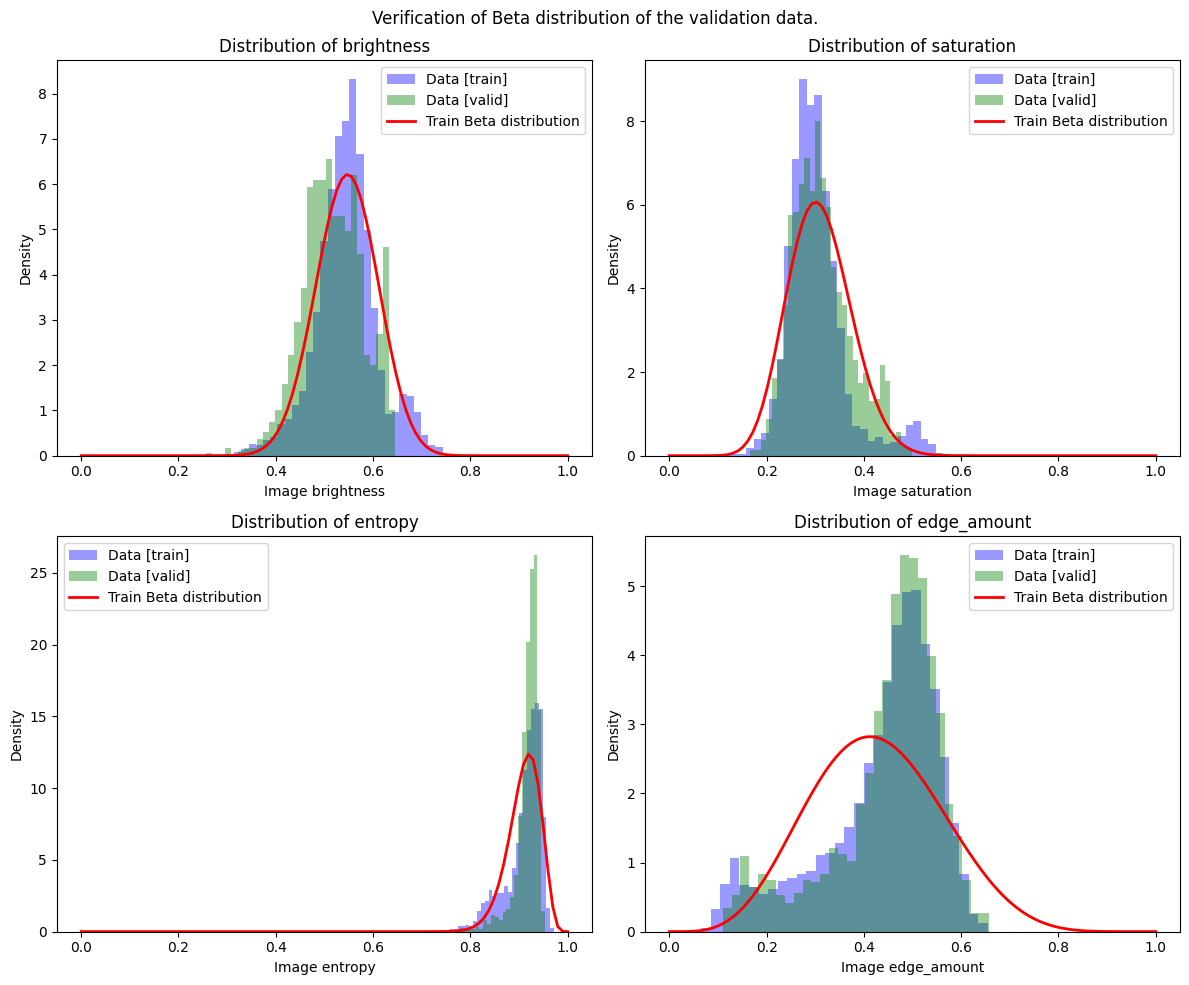

In [51]:
fig, axs = plt.subplots(2, 2, figsize=(12,10))
axs = axs.flatten()

for i, key in enumerate(beta_dist.keys()):
    # Generate PDF for the training beta distribution
    x = np.linspace(0, 1, 100)
    pdf = beta_dist[key].pdf(x)

    # Plot data histogram
    axs[i].hist(df_train[key], bins=30, density=True, alpha=0.4, label="Data [train]", color="b")
    axs[i].hist(df_valid[key], bins=30, density=True, alpha=0.4, label="Data [valid]", color="g")

    # Plot beta distribution PDF
    axs[i].plot(x, pdf, "r-", lw=2, label=f"Train Beta distribution")

    axs[i].set_title(f"Distribution of {key}")
    axs[i].set_xlabel(f'Image {key}')
    axs[i].set_ylabel('Density')
    axs[i].legend()

plt.suptitle("Verification of Beta distribution of the validation data.")
plt.tight_layout()
plt.show()

### A multi-dimensional approach

#### The copula-based technique

Fit a copula on the train data

In [52]:
# Transform the features into uniform space using the Beta CDF
df_train_uniform = pd.DataFrame()
for col in beta_dist.keys():
    df_train_uniform[col] = beta_dist[col].cdf(df_train[col])
df_train_uniform.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6410 entries, 0 to 6409
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   brightness   6410 non-null   float64
 1   saturation   6410 non-null   float64
 2   entropy      6410 non-null   float64
 3   edge_amount  6410 non-null   float64
dtypes: float64(4)
memory usage: 200.4 KB


In [53]:
# Fit a Gaussian copula on the uniform dataset
mu = np.mean(df_train_uniform, axis=0)
cov = np.cov(df_train_uniform, rowvar=False)
copula = stats.multivariate_normal(mean=mu, cov=cov)

Evaluate on the valid data

In [54]:
df_valid_uniform = pd.DataFrame()
for col in beta_dist.keys():
    df_valid_uniform[col] = beta_dist[col].cdf(df_valid[col])
df_valid_uniform.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458 entries, 0 to 1457
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   brightness   1458 non-null   float64
 1   saturation   1458 non-null   float64
 2   entropy      1458 non-null   float64
 3   edge_amount  1458 non-null   float64
dtypes: float64(4)
memory usage: 45.7 KB


In [55]:
# Compute the percentile on the copula distribution
p = np.percentile(copula.logpdf(df_train_uniform), 2)  # CUT OFF 2%

# Compute the logprob for the valid data
q = copula.logpdf(df_valid_uniform)

df_valid['OOD_by_copula'] = (q <= p)
df_valid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458 entries, 0 to 1457
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   brightness         1458 non-null   float32
 1   saturation         1458 non-null   float32
 2   entropy            1458 non-null   float32
 3   edge_amount        1458 non-null   float32
 4   OOD_p_brightness   1458 non-null   bool   
 5   OOD_p_saturation   1458 non-null   bool   
 6   OOD_p_entropy      1458 non-null   bool   
 7   OOD_p_edge_amount  1458 non-null   bool   
 8   OOD_by_any_1D      1458 non-null   bool   
 9   OOD_by_copula      1458 non-null   bool   
dtypes: bool(6), float32(4)
memory usage: 31.4 KB


In [56]:
print("# of OOD samples by copula method:", df_valid.OOD_by_copula.sum())

# of OOD samples by copula method: 30
